# Wprowadzenie do sztucznej inteligencji i uczenia maszynowego

### Ćwiczenia 4. — Zadania.

---

#### Zaimportuj biblioteki numpy, pandas, matplotlib i seaborn.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

#### Załaduj plik csv.
***
Do zmiennej `df` załaduj plik `cars.csv`.

In [117]:
df = pd.read_csv("cars.csv")

#### Wyświetl pierwsze 5 linijek obiektu ''df''.

In [7]:
df.head()

,manufacturer_name,model_name,transmission,color,odometer_value,year_produced,engine_fuel,engine_has_gas,engine_type,engine_capacity,...,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,duration_listed
0,Subaru,Outback,automatic,silver,190000,2010,gasoline,False,gasoline,2.5,...,True,True,True,False,True,False,True,True,True,16
1,Subaru,Outback,automatic,blue,290000,2002,gasoline,False,gasoline,3.0,...,True,False,False,True,True,False,False,False,True,83
2,Subaru,Forester,automatic,red,402000,2001,gasoline,False,gasoline,2.5,...,True,False,False,False,False,False,False,True,True,151
3,Subaru,Impreza,mechanical,blue,10000,1999,gasoline,False,gasoline,3.0,...,False,False,False,False,False,False,False,False,False,86
4,Subaru,Legacy,automatic,black,280000,2001,gasoline,False,gasoline,2.5,...,True,False,True,True,False,False,False,False,True,7


In [8]:
df.columns

Index(['manufacturer_name', 'model_name', 'transmission', 'color',
       'odometer_value', 'year_produced', 'engine_fuel', 'engine_has_gas',
       'engine_type', 'engine_capacity', 'body_type', 'has_warranty', 'state',
       'drivetrain', 'price_usd', 'is_exchangeable', 'location_region',
       'number_of_photos', 'up_counter', 'feature_0', 'feature_1', 'feature_2',
       'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7',
       'feature_8', 'feature_9', 'duration_listed'],
      dtype='object')

#### Narysuj wykres pudełkowego
***
Narysuj wykres, który przedstawi zależność typu silnika od ceny.

<Axes: title={'center': 'price_usd'}, xlabel='engine_type'>

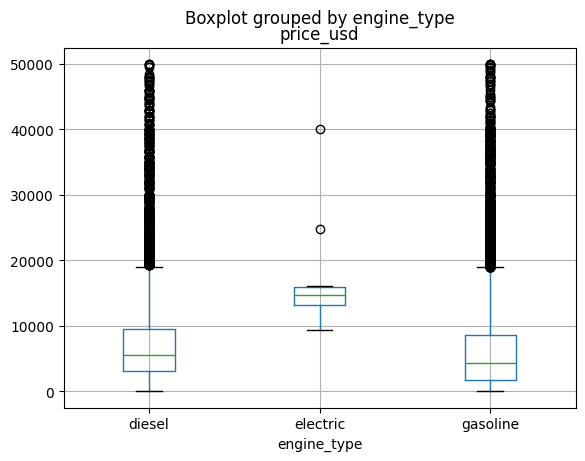

In [104]:
df.boxplot(column='price_usd', by='engine_type')

<Axes: xlabel='engine_type', ylabel='price_usd'>

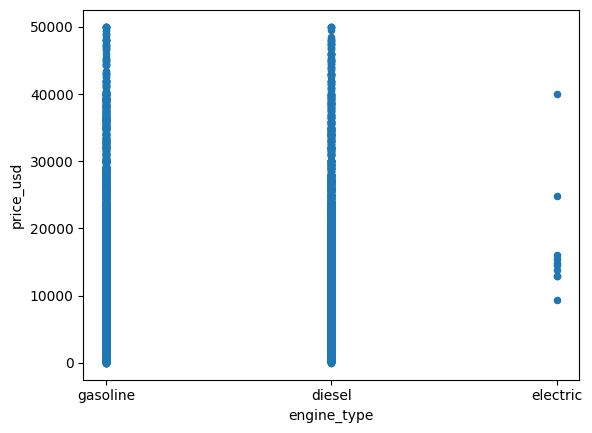

In [105]:
df.plot(y="price_usd", x="engine_type", kind="scatter")

#### Popraw wykres pudełkowego
***
Popraw wykres, tak żeby zakres cen na wykresie zaczynał się od 0.

(0.0, 52499.95)

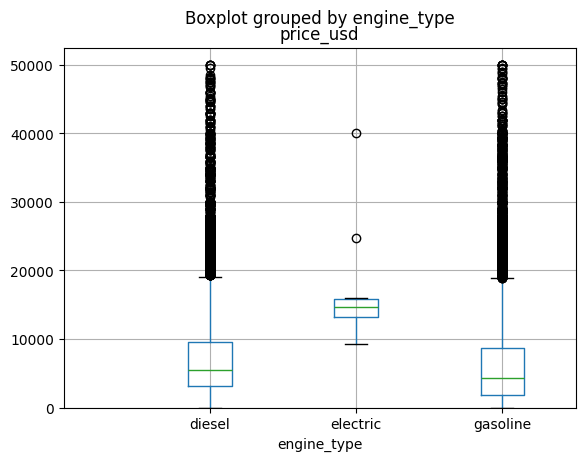

In [112]:
df.boxplot(column='price_usd', by='engine_type')
plt.xlim(0)
plt.ylim(0)

#### Stwórz dummy variables.
***
Stwórz obiekt `dummy_variable` z danych w kolumnie `'engine_type'`.

In [118]:
dummy_variable = pd.get_dummies(df["engine_type"])
dummy_variable

,diesel,electric,gasoline
0,False,False,True
1,False,False,True
2,False,False,True
3,False,False,True
4,False,False,True
...,...,...,...
38526,False,False,True
38527,True,False,False
38528,False,False,True
38529,False,False,True


#### Zmień nazwy kolumn w dummy variables.
***
Zmień nazwy kolumn w obiekcie `dummy_variable`, tak żeby każda kolumna zaczynała się od `'engine_type-'`.

In [119]:
dummy_variable_change = dummy_variable.rename(columns={"diesel":"engine_type_diesel", "electric":"engine_type_electric", "gasoline":"engine_type_gasoline"})

#### Dodaj dummy variables do DataFrame'a.
***
Połącz ze sobą stworzony obiekt `'dummy viariable'` z obiektem `'df'`.

In [120]:
df = pd.concat([df, dummy_variable_change],axis=1)
df.head()


,manufacturer_name,model_name,transmission,color,odometer_value,year_produced,engine_fuel,engine_has_gas,engine_type,engine_capacity,...,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,duration_listed,engine_type_diesel,engine_type_electric,engine_type_gasoline
0,Subaru,Outback,automatic,silver,190000,2010,gasoline,False,gasoline,2.5,...,False,True,False,True,True,True,16,False,False,True
1,Subaru,Outback,automatic,blue,290000,2002,gasoline,False,gasoline,3.0,...,True,True,False,False,False,True,83,False,False,True
2,Subaru,Forester,automatic,red,402000,2001,gasoline,False,gasoline,2.5,...,False,False,False,False,True,True,151,False,False,True
3,Subaru,Impreza,mechanical,blue,10000,1999,gasoline,False,gasoline,3.0,...,False,False,False,False,False,False,86,False,False,True
4,Subaru,Legacy,automatic,black,280000,2001,gasoline,False,gasoline,2.5,...,True,False,False,False,False,True,7,False,False,True


#### Stwórz pivot table.
***
Stwórz tabelę, która będzie obrazować jak typ karoserii (`'body_type'`) i kolor wypływają na średnią długość łącznego czasu wystawienia (`'duration_listed'`)

In [121]:
pivot_table = pd.pivot_table(df, values="duration_listed", index="body_type", columns="color",aggfunc="mean" )
pivot_table

color,black,blue,brown,green,grey,orange,other,red,silver,violet,white,yellow
body_type,,,,,,,,,,,,
cabriolet,111.608696,232.000000,333.000000,152.750000,416.200000,NaN,148.000000,227.750000,104.000000,64.000000,151.750000,182.666667
coupe,94.453416,68.696078,54.000000,91.218750,62.454545,99.428571,92.690476,83.333333,85.617978,52.500000,76.888889,70.272727
hatchback,78.265213,76.747384,69.764151,83.560976,77.682749,72.928571,81.451677,70.699399,80.612230,75.330097,87.665625,78.721519
liftback,44.000000,40.793651,39.260870,45.600000,44.328571,12.000000,47.700000,48.333333,41.926230,36.000000,43.353846,84.400000
limousine,348.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,43.200000,NaN
minibus,107.303030,89.282407,60.600000,66.388235,78.098039,110.923077,105.978261,80.450980,94.149351,74.000000,96.777154,84.866667
minivan,90.804527,78.119534,92.666667,63.891791,78.290828,174.142857,66.783465,79.878173,73.398374,104.354167,83.882143,39.764706
pickup,113.333333,244.066667,73.000000,57.833333,122.833333,152.333333,199.833333,142.428571,62.411765,NaN,131.304348,102.333333
sedan,82.117628,79.718913,76.827476,74.498866,76.415488,54.500000,75.998211,76.168715,80.787351,74.324841,80.703267,114.127273


#### Wypełnij brakujące wartości w pivot table.
***
Wszystkie komórki z brakującymi wartościami wypełnij średnią długością łącznego czasu wystawienia dla samochodów o takim samym typie karoserii.

In [122]:
pivot_table =pivot_table.fillna(pivot_table.mean(axis=0))
pivot_table

color,black,blue,brown,green,grey,orange,other,red,silver,violet,white,yellow
body_type,,,,,,,,,,,,
cabriolet,111.608696,232.000000,333.000000,152.750000,416.200000,100.233848,148.000000,227.750000,104.000000,64.000000,151.750000,182.666667
coupe,94.453416,68.696078,54.000000,91.218750,62.454545,99.428571,92.690476,83.333333,85.617978,52.500000,76.888889,70.272727
hatchback,78.265213,76.747384,69.764151,83.560976,77.682749,72.928571,81.451677,70.699399,80.612230,75.330097,87.665625,78.721519
liftback,44.000000,40.793651,39.260870,45.600000,44.328571,12.000000,47.700000,48.333333,41.926230,36.000000,43.353846,84.400000
limousine,348.000000,103.749484,94.723980,86.185922,105.804577,100.233848,95.035696,101.648065,79.691208,72.253542,43.200000,89.265786
minibus,107.303030,89.282407,60.600000,66.388235,78.098039,110.923077,105.978261,80.450980,94.149351,74.000000,96.777154,84.866667
minivan,90.804527,78.119534,92.666667,63.891791,78.290828,174.142857,66.783465,79.878173,73.398374,104.354167,83.882143,39.764706
pickup,113.333333,244.066667,73.000000,57.833333,122.833333,152.333333,199.833333,142.428571,62.411765,72.253542,131.304348,102.333333
sedan,82.117628,79.718913,76.827476,74.498866,76.415488,54.500000,75.998211,76.168715,80.787351,74.324841,80.703267,114.127273


#### Stwórz pivot table innym sposobem.
***
Najpierw pogrupuj dane po kolumnach `'body_type'` i `'color'`, a następnie dla każdej grupy policz średnią długość łącznego czasu wystawienia.

Następnie przekształć ten obiekt w pivot table za pomocą metody `df.pivot()`.

In [123]:
df_pivot = df.groupby(["body_type","color"], as_index=False)["duration_listed"].mean()
df_pivot.head()

,body_type,color,duration_listed
0,cabriolet,black,111.608696
1,cabriolet,blue,232.000000
2,cabriolet,brown,333.000000
3,cabriolet,green,152.750000
4,cabriolet,grey,416.200000


In [125]:
df_pivot_table = df_pivot.pivot(index='body_type', columns='color')

pivot_table =pivot_table.fillna(pivot_table.mean(axis=0))

pivot_table

color,black,blue,brown,green,grey,orange,other,red,silver,violet,white,yellow
body_type,,,,,,,,,,,,
cabriolet,111.608696,232.000000,333.000000,152.750000,416.200000,100.233848,148.000000,227.750000,104.000000,64.000000,151.750000,182.666667
coupe,94.453416,68.696078,54.000000,91.218750,62.454545,99.428571,92.690476,83.333333,85.617978,52.500000,76.888889,70.272727
hatchback,78.265213,76.747384,69.764151,83.560976,77.682749,72.928571,81.451677,70.699399,80.612230,75.330097,87.665625,78.721519
liftback,44.000000,40.793651,39.260870,45.600000,44.328571,12.000000,47.700000,48.333333,41.926230,36.000000,43.353846,84.400000
limousine,348.000000,103.749484,94.723980,86.185922,105.804577,100.233848,95.035696,101.648065,79.691208,72.253542,43.200000,89.265786
minibus,107.303030,89.282407,60.600000,66.388235,78.098039,110.923077,105.978261,80.450980,94.149351,74.000000,96.777154,84.866667
minivan,90.804527,78.119534,92.666667,63.891791,78.290828,174.142857,66.783465,79.878173,73.398374,104.354167,83.882143,39.764706
pickup,113.333333,244.066667,73.000000,57.833333,122.833333,152.333333,199.833333,142.428571,62.411765,72.253542,131.304348,102.333333
sedan,82.117628,79.718913,76.827476,74.498866,76.415488,54.500000,75.998211,76.168715,80.787351,74.324841,80.703267,114.127273


#### Zastosuj stylowanie.
***
Weź stworzony komórkę wyżej obiekt (`df_pivot_table`) i zastosuj na nim stylowanie z następującymi elementami:
- tytuł wykresu
- tło komórki ma mieć różny kolor w zależności od wielkości w komórce
- sformatowane wartości w komórce (liczby całkowite bez przecinka, wartości brakujące jaki napis "brak"
- podświetlenie największych wartości
- ustawienie odpowiednich marginesów w komórkach (padding)

In [58]:
df_pivot_table.style\
    .format('{:.0f}', na_rep="brak")\
    .background_gradient(cmap="BuGn")\
    .set_caption("Średni czas wystawienia według typu")\
    .set_properties(**{'padding': '8px'})\
    .highlight_max()

#### Narysuj heatmapę wartości z pivot table.
***

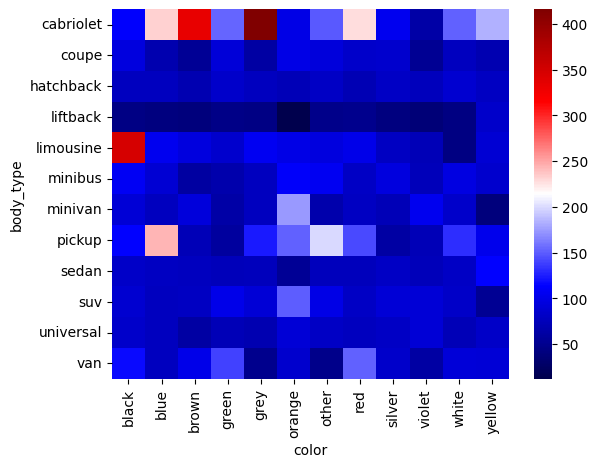

In [ ]:
sns.heatmap(pivot_table, cmap='seismic')

#### Stwórz scatter plot przy pomocy pandasa.
***
Zobrazuj zależność pomiędzy przebiegiem a ceną, używając do tego funkcji z biblioteki pandas.

<Axes: title={'center': 'Przebieg a cena'}, xlabel='odometer_value', ylabel='price_usd'>

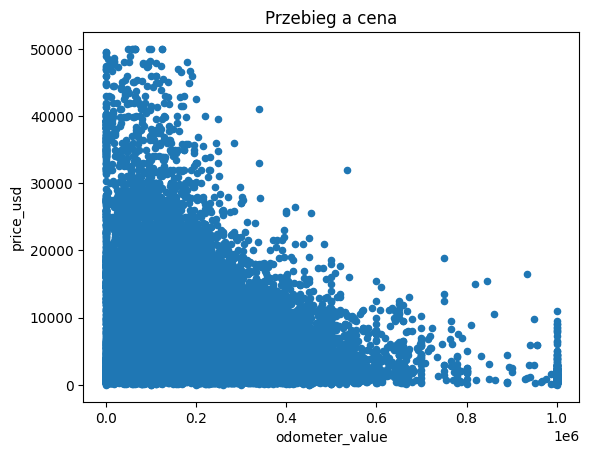

In [74]:
df.plot(kind='scatter', x='odometer_value', y='price_usd', title='Przebieg a cena')

#### Stwórz scatter plot przy pomocy matplotliba.
***
Zobrazuj zależność pomiędzy przebiegiem a ceną, używając do tego funkcji z biblioteki matplotliba.

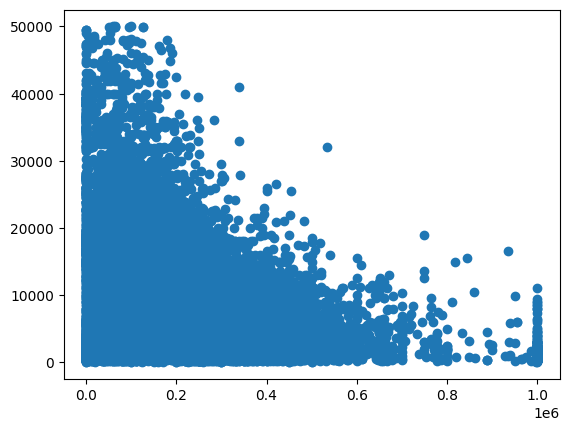

In [73]:
plt.scatter(df['odometer_value'], df['price_usd'])

#### Stwórz scatter plot przy pomocy seaborna.
***
Zobrazuj zależność pomiędzy przebiegiem a ceną, używając do tego funkcji z biblioteki seaborna.

<Axes: xlabel='price_usd', ylabel='odometer_value'>

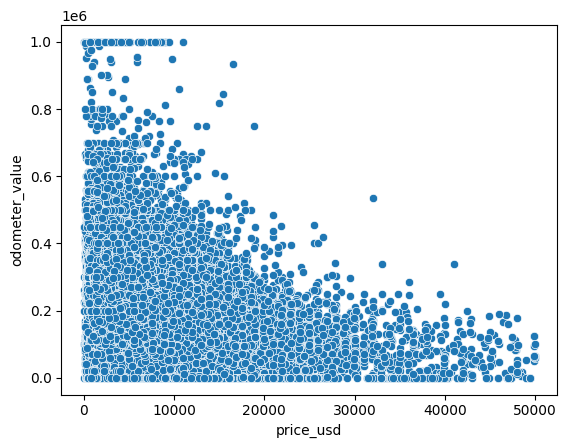

In [75]:
sns.scatterplot(x="price_usd", y="odometer_value", data=df)

#### Popraw scatter plot przy pomocy seaborna.
***
Zmniejsz rozmiar znaczników i zmień ich kolor na zielony. Ogranicz oś x i y tak, żeby zaczynały się od zera. Usuń obwódkę wokół znaczników (`edgecolor`). Usuń ramkę wokół wykresu (`sns.despine`).

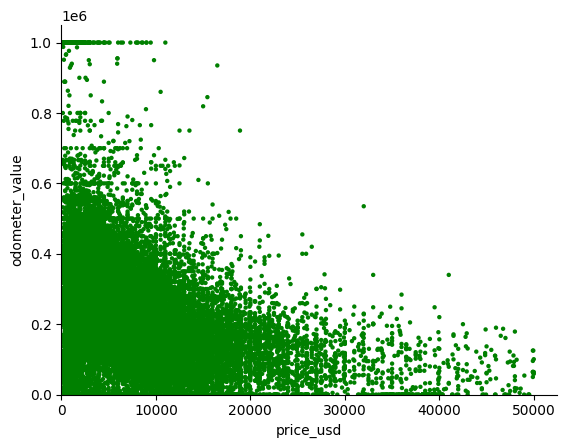

In [98]:
osie = sns.scatterplot(edgecolor='none', x="price_usd", y="odometer_value",color='green', s=10, data=df)
osie.set_xlim(left=0)
osie.set_ylim(bottom=0)
sns.despine()

#### Podziel na biny.
***
Podziel wartości cen samochodów na 5 binów ('Low', 'Medium-Low', 'Medium', 'Medium-High', 'High').

In [130]:
bins = np.linspace(min(df['price_usd']), max(df['price_usd']), 6)

bins

array([1.00000e+00, 1.00008e+04, 2.00006e+04, 3.00004e+04, 4.00002e+04,
       5.00000e+04])

#### Rozdziel na biny.
***
Stwórz nową kolumnę `'price_usd_binned'` i przyporządkuj każdą wartość do jednego z 5 binów ('Low', 'Medium-Low', 'Medium', 'Medium-High', 'High').

In [138]:
group_names = ['Low', 'Medium-Low', 'Medium', 'Medium-High', 'High']

df["price_usd_binned"] = pd.cut(df['price_usd'], bins, 
                                     labels=group_names, include_lowest=True )
df[['price_usd','price_usd_binned']]


,price_usd,price_usd_binned
0,10900.00,Medium-Low
1,5000.00,Low
2,2800.00,Low
3,9999.00,Low
4,2134.11,Low
...,...,...
38526,2750.00,Low
38527,4800.00,Low
38528,4300.00,Low
38529,4000.00,Low


In [139]:
df[df['price_usd_binned'] == 'High']

,manufacturer_name,model_name,transmission,color,odometer_value,year_produced,engine_fuel,engine_has_gas,engine_type,engine_capacity,...,feature_5,feature_6,feature_7,feature_8,feature_9,duration_listed,engine_type_diesel,engine_type_electric,engine_type_gasoline,price_usd_binned
1218,Kia,Sorento,automatic,black,0,2019,diesel,False,diesel,2.2,...,True,True,True,True,True,83,True,False,False,High
4868,Lexus,RX,automatic,white,43436,2017,gasoline,False,gasoline,2.0,...,True,True,True,True,True,26,False,False,True,High
4871,Lexus,RX,automatic,silver,39855,2016,gasoline,False,gasoline,3.5,...,True,True,True,True,True,22,False,False,True,High
4876,Lexus,NX,mechanical,white,10,2019,gasoline,False,gasoline,2.0,...,False,False,False,False,False,339,False,False,True,High
4924,Lexus,RX,automatic,white,17000,2019,gasoline,False,gasoline,2.0,...,True,False,True,True,True,13,False,False,True,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35399,Mercedes-Benz,S500,automatic,black,125000,2014,gasoline,False,gasoline,4.7,...,True,True,True,True,True,144,False,False,True,High
35400,Mercedes-Benz,GL500,automatic,silver,46000,2013,gasoline,False,gasoline,4.7,...,True,True,True,True,True,140,False,False,True,High
35733,Mercedes-Benz,V250,automatic,violet,164000,2015,diesel,False,diesel,2.2,...,True,True,True,True,True,50,True,False,False,High
36081,Mercedes-Benz,GL400,automatic,grey,87000,2014,gasoline,False,gasoline,3.0,...,True,True,True,True,True,141,False,False,True,High


#### Narysuj histogram z binami za pomocą pandasa.
***
Stwórz histogram, który sam podzieli wartości z kolumny `'price_usd'` na 5 binów.

Text(0.5, 1.0, 'Histogram price_usd')

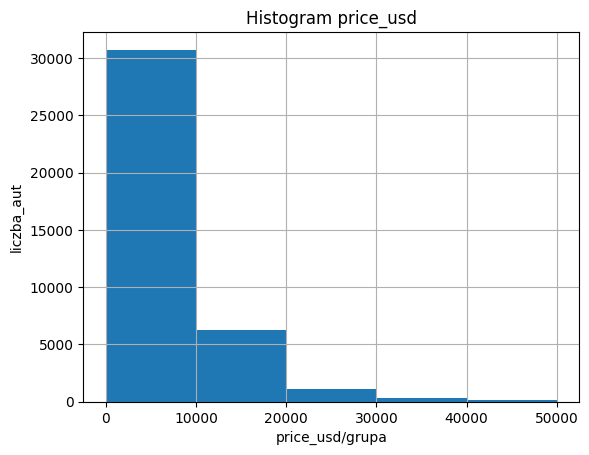

In [156]:
df['price_usd'].hist(bins=5)
plt.xlabel('price_usd/grupa')
plt.ylabel('liczba_aut')
plt.title('Histogram price_usd')

#### Narysuj histogram z binami za pomocą matplotliba.
***
Stwórz histogram, który sam podzieli wartości z kolumny `'price_usd'` na 5 binów.

Text(0.5, 1.0, 'Histogram price_usd')

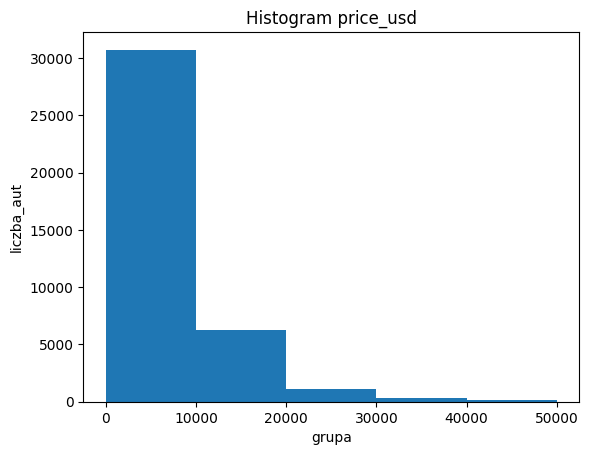

In [158]:
plt.hist(df['price_usd'], bins=5)
plt.xlabel("grupa")
plt.ylabel("liczba_aut")
plt.title("Histogram price_usd")

#### Narysuj histogram z binami za pomocą matplotliba.
***
Stwórz histogram wartości z kolumny `'price_usd_binned'`.

([<matplotlib.axis.XTick at 0x7e2d4cf3e5c0>,
 [Text(5000.9, 0, 'Low'),
  Text(15000.699999999999, 0, 'Medium-Low'),
  Text(25000.5, 0, 'Medium'),
  Text(35000.299999999996, 0, 'Medium-High'),
  Text(45000.1, 0, 'High')])

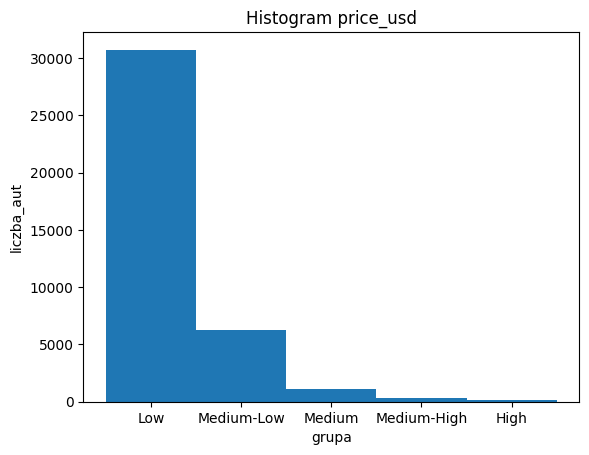

In [159]:
plt.hist(df['price_usd'], bins=5)
plt.xlabel("grupa")
plt.ylabel("liczba_aut")
plt.title("Histogram price_usd")
bin_centers = 0.5 *(bins[:-1] + bins[1:])
plt.xticks(bin_centers, group_names)

#### Narysuj histogram z binami za pomocą seaborna.
***
Stwórz histogram, który sam podzieli wartości z kolumny `'price_usd'` na 5 binów.

<Axes: xlabel='price_usd', ylabel='Count'>

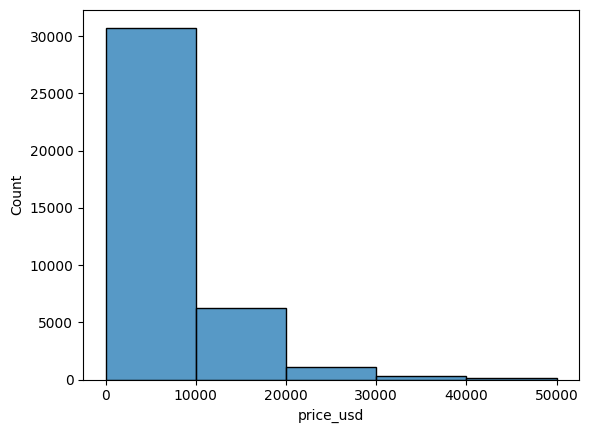

In [161]:
sns.histplot(df["price_usd"],bins=5)

#### Narysuj histogram z binami za pomocą seaborna.
***
Stwórz histogram wartości z kolumny `'price_usd_binned'`.

<Axes: xlabel='price_usd_binned', ylabel='Count'>

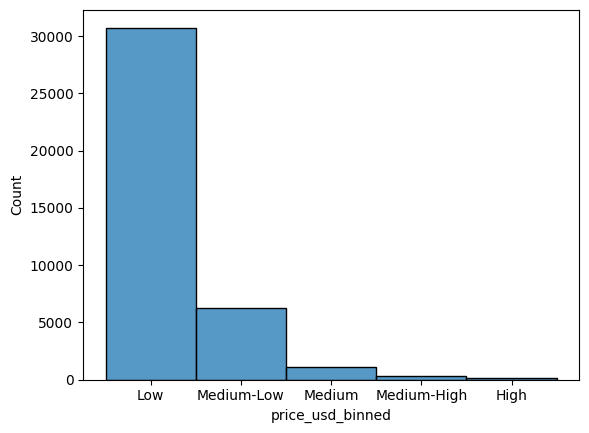

In [166]:
sns.histplot(df["price_usd_binned"])

#### Zmień histogram z binami za pomocą seaborna.
***
Nadaj tytuł wykresowi, obróć nazwy binów o 90 stopni, zmień kolor słupków na czerwony, pogrub kontur słupków i zmień kolor konturu na czarny.

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Low'),
  Text(1, 0, 'Medium-Low'),
  Text(2, 0, 'Medium'),
  Text(3, 0, 'Medium-High'),
  Text(4, 0, 'High')])

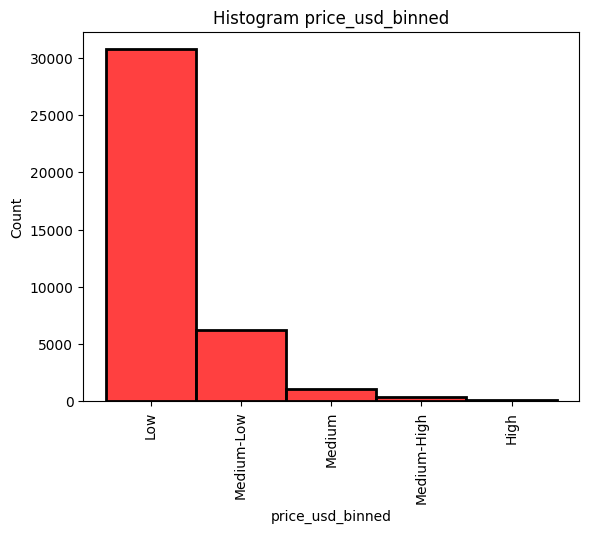

In [172]:
sns.histplot(df["price_usd_binned"],color="red",edgecolor="black", linewidth=2)
plt.title("Histogram price_usd_binned")
plt.xticks(rotation=90)

#### Pokaż na wykresie, której wartości danych jest najwięcej.
***
Pokaż na wykresie, której marki samochodów jest najwięcej.
NIE używaj do tego `sns.histplot()`.

In [173]:
df.head()

,manufacturer_name,model_name,transmission,color,odometer_value,year_produced,engine_fuel,engine_has_gas,engine_type,engine_capacity,...,feature_5,feature_6,feature_7,feature_8,feature_9,duration_listed,engine_type_diesel,engine_type_electric,engine_type_gasoline,price_usd_binned
0,Subaru,Outback,automatic,silver,190000,2010,gasoline,False,gasoline,2.5,...,True,False,True,True,True,16,False,False,True,Medium-Low
1,Subaru,Outback,automatic,blue,290000,2002,gasoline,False,gasoline,3.0,...,True,False,False,False,True,83,False,False,True,Low
2,Subaru,Forester,automatic,red,402000,2001,gasoline,False,gasoline,2.5,...,False,False,False,True,True,151,False,False,True,Low
3,Subaru,Impreza,mechanical,blue,10000,1999,gasoline,False,gasoline,3.0,...,False,False,False,False,False,86,False,False,True,Low
4,Subaru,Legacy,automatic,black,280000,2001,gasoline,False,gasoline,2.5,...,False,False,False,False,True,7,False,False,True,Low


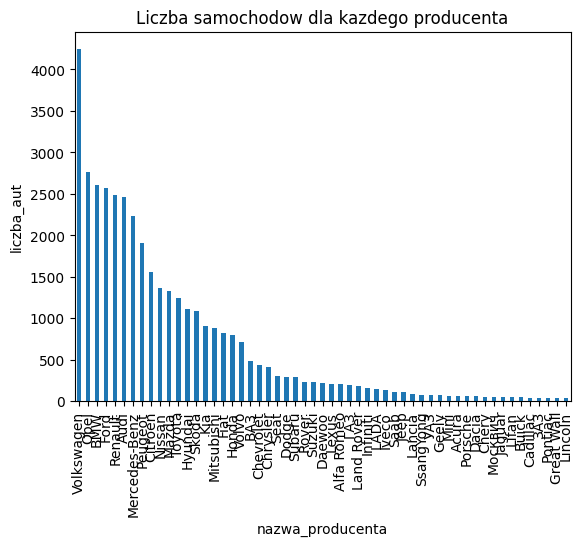

In [202]:
df.groupby("manufacturer_name").size().sort_values(ascending=False).plot(kind='bar')
plt.xlabel('nazwa_producenta')
plt.ylabel('liczba_aut')
plt.title('Liczba samochodow dla kazdego producenta')
plt.xticks(rotation=90)
plt.show()

#### Popraw wykres, przedstawiający której wartości danych jest najwięcej.
***
Zmień podpisy przy osi x, żeby na nachodziły na siebie (obróć i zmniejsz czcionkę).
Ustaw słupki według malejącej liczby wystąpień - argument `'order'` (`df['manufacturer_name'].value_counts().index` zwraca listę kolumny w kolejności, jeśli chodzi o malejącą liczbę wystąpień).

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
        51, 52, 53, 54]),
 [Text(0, 0, 'Volkswagen'),
  Text(1, 0, 'Opel'),
  Text(2, 0, 'BMW'),
  Text(3, 0, 'Ford'),
  Text(4, 0, 'Renault'),
  Text(5, 0, 'Audi'),
  Text(6, 0, 'Mercedes-Benz'),
  Text(7, 0, 'Peugeot'),
  Text(8, 0, 'Citroen'),
  Text(9, 0, 'Nissan'),
  Text(10, 0, 'Mazda'),
  Text(11, 0, 'Toyota'),
  Text(12, 0, 'Hyundai'),
  Text(13, 0, 'Skoda'),
  Text(14, 0, 'Kia'),
  Text(15, 0, 'Mitsubishi'),
  Text(16, 0, 'Fiat'),
  Text(17, 0, 'Honda'),
  Text(18, 0, 'Volvo'),
  Text(19, 0, 'ВАЗ'),
  Text(20, 0, 'Chevrolet'),
  Text(21, 0, 'Chrysler'),
  Text(22, 0, 'Seat'),
  Text(23, 0, 'Dodge'),
  Text(24, 0, 'Subaru'),
  Text(25, 0, 'Rover'),
  Text(26, 0, 'Suzuki'),
  Text(27, 0, 'Daewoo'),
  Text(28, 0, 'Lexus'),
  Text(29, 0, 'Alfa Romeo'),
  Te

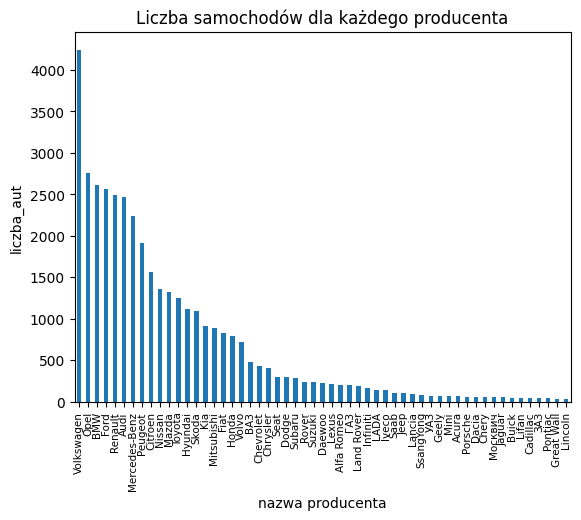

In [214]:
df["manufacturer_name"].value_counts().plot(kind='bar')
plt.xlabel('nazwa producenta')
plt.ylabel('liczba_aut')
plt.title('Liczba samochodów dla każdego producenta')
plt.xticks(rotation=90, fontsize=7.5)


#### Policz korelacje.
***
Policz korelację między wszystkimi kolumnami zawierającymi dane numeryczne.

In [215]:
df.corr(numeric_only=True)

,odometer_value,year_produced,engine_has_gas,engine_capacity,has_warranty,price_usd,is_exchangeable,number_of_photos,up_counter,feature_0,...,feature_5,feature_6,feature_7,feature_8,feature_9,duration_listed,engine_type_diesel,engine_type_electric,engine_type_gasoline,liczba_aut
odometer_value,1.000000,-0.488679,0.057786,0.105704,-0.189498,-0.421204,0.042342,-0.143708,-0.020961,0.105917,...,-0.240968,-0.166413,-0.254539,-0.208844,-0.087875,-0.000428,0.246473,-0.020725,-0.245718,NaN
year_produced,-0.488679,1.000000,-0.074686,0.005059,0.209231,0.705511,-0.057937,0.258180,0.007945,-0.346980,...,0.435241,0.345745,0.457091,0.465969,0.247439,-0.017001,0.019254,0.022086,-0.020004,NaN
engine_has_gas,0.057786,-0.074686,1.000000,0.084579,-0.020667,-0.062528,0.018646,-0.032101,0.000058,0.004089,...,-0.031172,-0.030140,-0.036635,-0.041992,-0.005855,0.018264,-0.134822,-0.003067,0.134900,NaN
engine_capacity,0.105704,0.005059,0.084579,1.000000,-0.054583,0.296597,0.081636,0.106691,0.079152,-0.142097,...,0.273235,0.284419,0.202070,0.240077,0.245828,0.080081,0.089979,NaN,-0.089979,NaN
has_warranty,-0.189498,0.209231,-0.020667,-0.054583,1.000000,0.285532,0.117775,0.084045,-0.023087,0.149966,...,-0.044887,-0.021049,-0.024925,-0.058637,-0.094622,-0.061798,-0.048717,-0.001750,0.048768,NaN
price_usd,-0.421204,0.705511,-0.062528,0.296597,0.285532,1.000000,-0.000503,0.316859,0.057382,-0.223896,...,0.434471,0.451714,0.498547,0.449131,0.266156,0.033524,0.084963,0.027133,-0.085873,NaN
is_exchangeable,0.042342,-0.057937,0.018646,0.081636,0.117775,-0.000503,1.000000,0.103725,0.106213,0.013844,...,-0.022763,0.000588,-0.021710,0.000701,0.031275,0.026897,-0.000618,0.001598,0.000563,NaN
number_of_photos,-0.143708,0.258180,-0.032101,0.106691,0.084045,0.316859,0.103725,1.000000,0.073891,-0.106468,...,0.162720,0.183741,0.192636,0.197508,0.132390,-0.028255,0.014665,0.010183,-0.015010,NaN
up_counter,-0.020961,0.007945,0.000058,0.079152,-0.023087,0.057382,0.106213,0.073891,1.000000,-0.022423,...,0.039292,0.033456,0.035347,0.063588,0.037183,0.698116,0.003500,-0.000709,-0.003475,NaN
feature_0,0.105917,-0.346980,0.004089,-0.142097,0.149966,-0.223896,0.013844,-0.106468,-0.022423,1.000000,...,-0.404747,-0.247182,-0.325759,-0.458741,-0.638831,-0.068888,-0.003311,-0.008770,0.003610,NaN


#### Narysuj heatmapę korelacji.
***
Spróbuj różnych wartości argumentu `'cmap'`.

<Axes: >

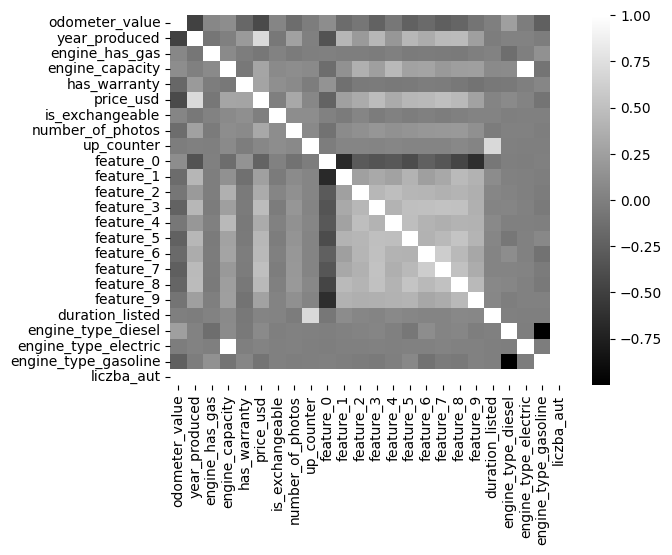

In [216]:
sns.heatmap(df.corr(numeric_only=True), cmap='gray')

#### Narysuj wykres dla dwóch zmiennych z dodatnią korelacją.
***
Na heatmapie znajdź dwie zmienne z dodatnią korelacją.
Narysuj ich wykres wraz z linią regresji.
Zmień kolor linii regresji na czerwony i upewnij się, że osie x i y zaczynają się i kończą przy odpowiednich wartościach.

In [239]:
df[["engine_type_electric", "engine_type_diesel"]].corr()


,engine_type_electric,engine_type_diesel
engine_type_electric,1.000000,-0.011413
engine_type_diesel,-0.011413,1.000000


#### Narysuj wykres dla dwóch zmiennych z korelacją bliską zera.
***
Na heatmapie znajdź dwie zmienne z korelacją bliską zera.
Narysuj ich wykres wraz z linią regresji.
Zmień kolor linii regresji na czerwony i upewnij się, że osie x i y zaczynają się i kończą przy odpowiednich wartościach.

(0.0, 52499.95)

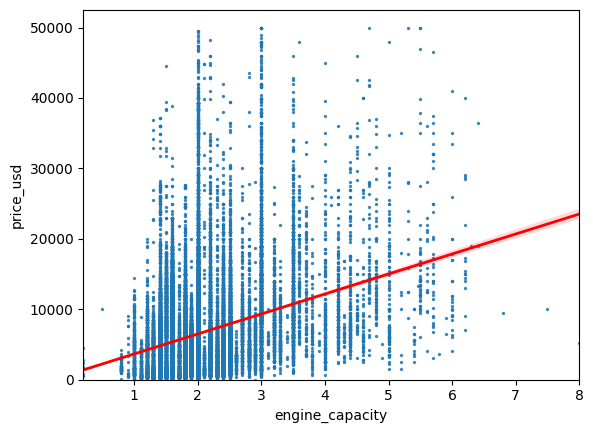

In [229]:
sns.regplot(x="engine_capacity", y="price_usd", data=df, scatter_kws={'s': 2}, line_kws={'color': 'red', 'lw': 2})
plt.xlim(df["engine_capacity"].min(), df["engine_capacity"].max())
plt.ylim(0, )

#### Narysuj wykres dla dwóch zmiennych z ujemną korelacją.
***
Na heatmapie znajdź dwie zmienne z ujemną korelacją.
Narysuj ich wykres wraz z linią regresji.
Zmień kolor linii regresji na czerwony i upewnij się, że osie x i y zaczynają się i kończą przy odpowiednich wartościach.

(0.0, 1.0500000000000003)

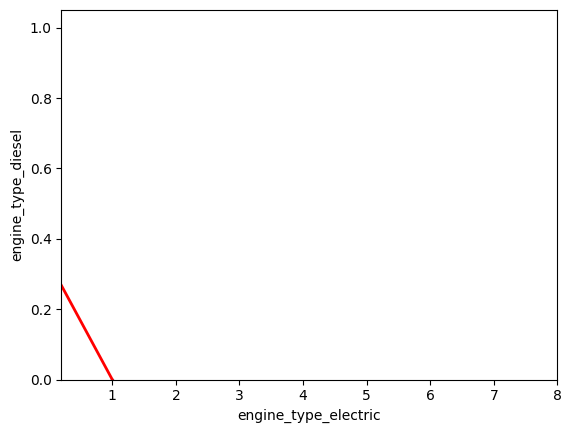

In [240]:
sns.regplot(x="engine_type_electric", y="engine_type_diesel", data=df, scatter_kws={'s': 2}, line_kws={'color': 'red', 'lw': 2})
plt.xlim(df["engine_capacity"].min(), df["engine_capacity"].max())
plt.ylim(0, )
 

#### Wybierz dane dla konkretnej marki samochodu
***
Stwórz nowy obiekt `'df_manufacturer'`, w którym będą znajdować się tylko samochody marki `'Land Rover'`.

In [244]:
df_manufacturer =df[df["manufacturer_name"]=="Land Rover"]
df_manufacturer.head()

,manufacturer_name,model_name,transmission,color,odometer_value,year_produced,engine_fuel,engine_has_gas,engine_type,engine_capacity,...,feature_6,feature_7,feature_8,feature_9,duration_listed,engine_type_diesel,engine_type_electric,engine_type_gasoline,price_usd_binned,liczba_aut
31438,Land Rover,Range Rover,automatic,blue,331000,2005,gasoline,False,gasoline,4.4,...,True,True,True,True,3,False,False,True,Low,38531
31439,Land Rover,Range Rover,automatic,red,189000,2006,gasoline,False,gasoline,4.2,...,False,False,True,True,61,False,False,True,Low,38531
31440,Land Rover,Range Rover Evoque,automatic,white,145000,2012,gasoline,False,gasoline,2.0,...,False,False,False,False,23,False,False,True,Medium-Low,38531
31441,Land Rover,Range Rover,automatic,silver,400000,1997,diesel,False,diesel,2.5,...,False,True,True,True,102,True,False,False,Low,38531
31442,Land Rover,Freelander,automatic,silver,213000,2001,gasoline,False,gasoline,2.5,...,False,False,True,True,22,False,False,True,Low,38531


#### Podziel dane ze względu na model samochodu.
***
Pogrupuj dane ze względu na model samochodu i dla każdej podgrupy policzyć średnią cenę i liczbę obiektów w danej podgrupie.

In [245]:
df_manufacturer.groupby(["model_name"]).agg({"price_usd":"mean","model_name":"count"})

,price_usd,model_name
model_name,,
Defender,21592.855000,4
Discovery,15618.862069,29
Discovery Sport,33699.800000,5
Freelander,6926.858723,47
Range Rover,12800.902439,41
Range Rover Evoque,24555.400000,20
Range Rover Sport,19647.644474,38


#### Stwórz wykres skrzypcowy przedstawiający rozkład cen ze względu na model samochodu
***
Korzystając z danych zawartych w obiekcie `'df_manufacturer'`, zwizualizuj rozkład cen w zależności od modelu.

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Range Rover'),
  Text(1, 0, 'Range Rover Evoque'),
  Text(2, 0, 'Freelander'),
  Text(3, 0, 'Range Rover Sport'),
  Text(4, 0, 'Discovery'),
  Text(5, 0, 'Discovery Sport'),
  Text(6, 0, 'Defender')])

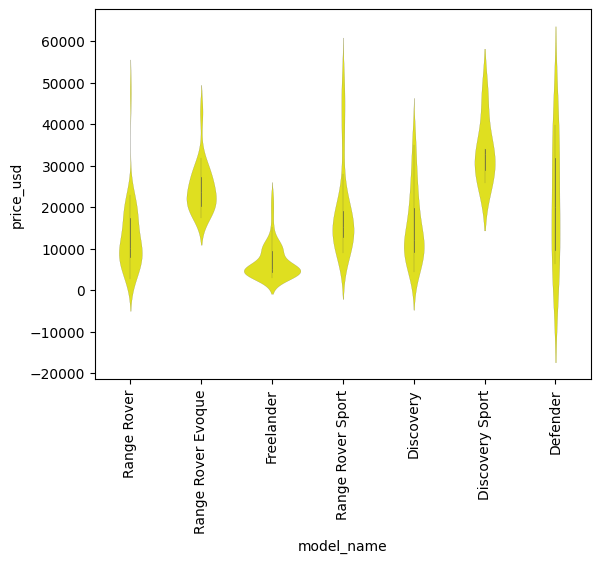

In [249]:
sns.violinplot(x='model_name', y='price_usd', data=df_manufacturer, color='yellow', linewidth=0.1)
plt.xticks(rotation=90)

#### Popraw wykres skrzypcowy przedstawiający rozkład cen ze względu na model samochodu
***
Zmniejsz grubość konturów, ogranicz oś y, żeby zaczynała się w zerze, zmień podpisy przy osi x, żeby na nachodziły na siebie.

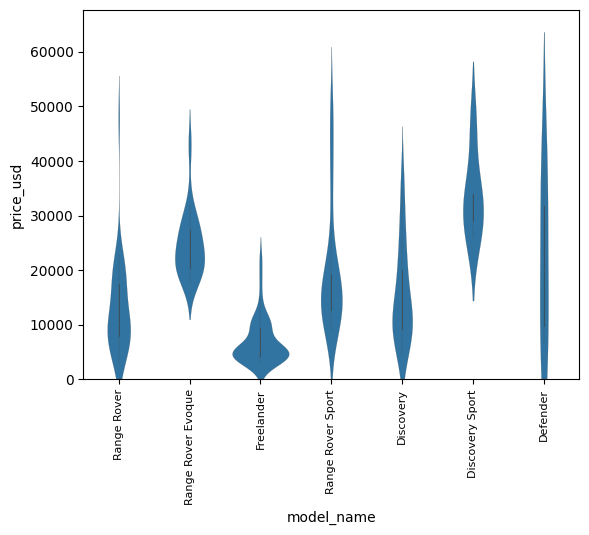

In [252]:

sns.violinplot(x='model_name', y='price_usd', data=df_manufacturer, linewidth=0.1)
plt.ylim(0,)
plt.xticks(rotation=90)
plt.tick_params(axis='x', labelsize=8)

#### Skorzystaj z catplot, żeby stworzyć kilka wykresów skrzypcowych.
***
Wykresy skrzypcowe mają ilustrować rozkład przebiegu (`'odometer_value'`) w zależności od rodzaju napędu (`'drivetrain'`) i rodzaju skrzyni biegów (`'transmission'`). W każdej kolumnie będzie osobny wykres dla każdego rodzaju silnika (`'engine_type'`).

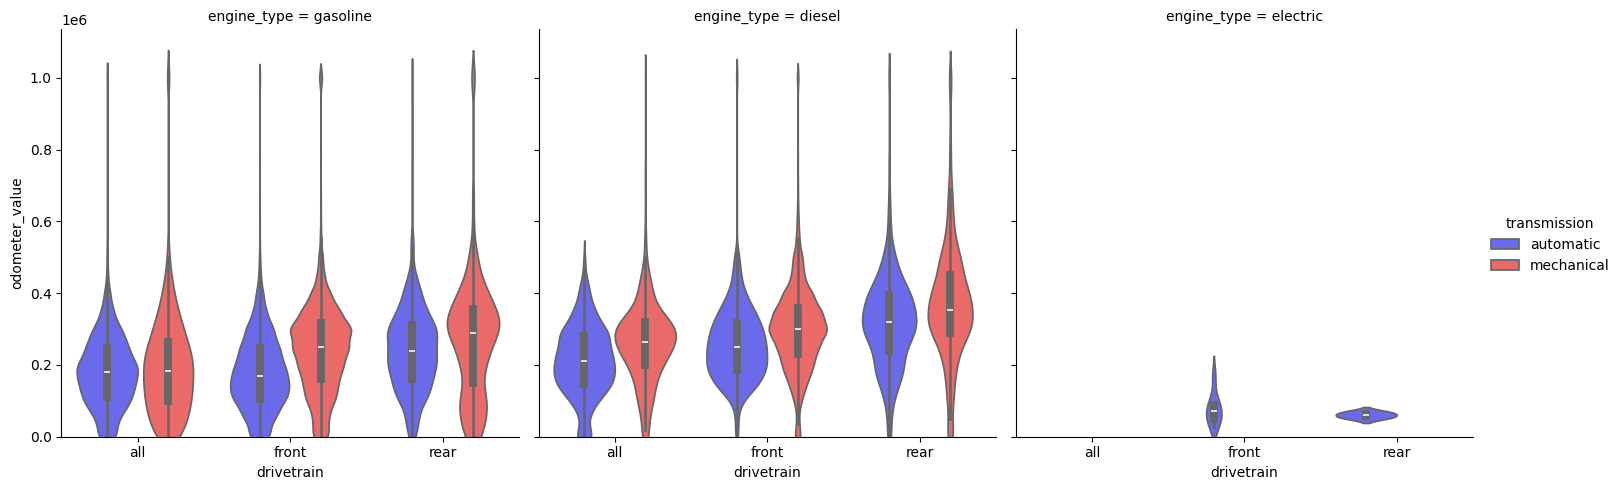

In [ ]:
# ogólny wykres kategorii, który umożliwia rysowanie różnych rodzajów wykresów dla różnych typów danych, w tym także dodawanie subplots
sns.catplot(x='drivetrain', y='odometer_value', hue='transmission', kind='violin', col='engine_type', data=df, palette='seismic')
plt.ylim(0,)